# Model v2 — Empirical Bayes

---

## Model

Each race $r \in \{1,\dots,R\}$ receives batches of votes at times $t = 1, \dots, T$. The observed Democratic proportion in batch $(r, t)$ is modeled as:

$$b_{r,t} \;\sim\; \mathcal{N}\!\left(\,p_r^{(0)} + s_r + s_g,\;\frac{\sigma_{\text{batch}}}{n_{r,t}^{0.25}}\right)$$

where $p_r^{(0)}$ is the **baseline** Democratic proportion for race $r$ (cumulative proportion at the earliest observed batch), $n_{r,t}$ is the total votes in batch $(r,t)$, and the $n^{0.25}$ denominator shrinks observation noise for larger batches (v2 extension over v1's constant noise).

**Latent structure (non-centered parameterization):**

$$s_r = z_r \cdot \sigma_r, \quad z_r \sim \mathcal{N}(0,1) \qquad \text{(race-level shift)}$$
$$s_g = \mu_g + z_g \cdot \sigma_g, \quad z_g \sim \mathcal{N}(0,1) \qquad \text{(global shift)}$$

| Parameter | Role |
|---|---|
| $\sigma_r$ | Cross-race heterogeneity — how much individual races diverge from the global trend |
| $\mu_g$ | Mean global shift from baseline to final (positive = Democrats gain as counting continues) |
| $\sigma_g$ | Election-level uncertainty around $\mu_g$ |
| $\sigma_{\text{batch}}$ | Baseline observation noise (before batch-size scaling) |

---

## Empirical Bayes: what changes from v1

In **v1**, all four variance hyperparameters use uninformative `HalfNormal(0.05)` priors and $\mu_g \sim \mathcal{N}(0, 0.05)$.

In **v2-EB**, three of the four are replaced with **semi-informative priors** anchored to moment estimates from the 2022 California election. $\sigma_g$ stays at `HalfNormal(0.05)` — it reflects within-election randomness around $\mu_g$, which 2022 cannot identify (single election = single draw of the global shift).

---

## Estimating EB hyperparameters from 2022

For each race $r$ in the 2022 data let $F_r$ be the final Democratic proportion and $p_r^{(0)}$ the proportion at the earliest drop. Define:

$$\Delta_r = F_r - p_r^{(0)} \qquad \text{(total shift from baseline to final)}$$

Three quantities are estimated from the 2022 races (SD-16 excluded — uncontested):

| Estimate | Formula | Prior target |
|---|---|---|
| $\hat{\mu}_g$ | $\text{mean}(\Delta_r)$ | location of $\mu_g$ prior |
| $\hat{\sigma}_r$ | $\text{std}(\Delta_r)$ | scale of $\sigma_r$ prior |
| $\hat{\sigma}_\varepsilon$ | pooled SD of $p_{r,t} - \bar{F}_r$ across all drops | scale of $\sigma_{\text{batch}}$ prior |

**Rescaling $\hat{\sigma}_\varepsilon$ to $\hat{\sigma}_{\text{batch}}$**: the likelihood uses $\sigma_{\text{batch}} / n^{0.25}$, so the effective noise at a batch of size $n$ is $\sigma_{\text{batch}} / n^{0.25}$. Inverting:

$$\hat{\sigma}_{\text{batch}} = \hat{\sigma}_\varepsilon \cdot \mathbb{E}[n^{0.25}]$$

where the expectation is taken over all 2024 batches.

---

## The E+6 baseline problem

The 2022 data starts at **E+6** (six days after election night), while 2024 starts at **E+3**. This means:
- $\hat{\mu}_g$ underestimates the true E+3→final shift (some shift already occurred before E+6)
- $\hat{\sigma}_r$ also underestimates cross-race spread for the same reason

Neither bias is scale-invariant, so we cannot simply rescale. The fix is to **trust the direction but inflate the variance**:

$$\tau = \max(|\hat{\mu}_g|,\; \hat{\sigma}_r)$$

The prior on $\mu_g$ becomes $\mathcal{N}(\hat{\mu}_g,\, \tau^2)$ — centered at the 2022 estimate but wide enough that the true (unknown) E+3 value is plausible.

---

## Prior specifications (two variants)

### Version A — LogNormal-EB

LogNormal places the prior **median** exactly at the point estimate with a heavy upper tail, which is appropriate when the parameter is certainly positive and could be larger than observed in 2022.

$$\sigma_r \sim \text{LogNormal}(\log\hat{\sigma}_r,\; 0.5), \quad \sigma_{\text{batch}} \sim \text{LogNormal}(\log\hat{\sigma}_{\text{batch}},\; 0.5)$$
$$\mu_g \sim \mathcal{N}(\hat{\mu}_g,\; \tau^2), \quad \sigma_g \sim \text{HalfNormal}(0.05)$$

### Version B — HalfNormal-EB

HalfNormal with scale $2.5\hat{\theta}$ puts the 95th percentile near $5\hat{\theta}$, giving the parameter room to be much larger than the 2022 estimate while still concentrating mass near it.

$$\sigma_r \sim \text{HalfNormal}(2.5\,\hat{\sigma}_r), \quad \sigma_{\text{batch}} \sim \text{HalfNormal}(2.5\,\hat{\sigma}_{\text{batch}})$$
$$\mu_g \sim \mathcal{N}(\hat{\mu}_g,\; \tau^2), \quad \sigma_g \sim \text{HalfNormal}(0.05)$$


In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import os
import re
import seaborn as sns
import json
from scipy.stats import rankdata

In [3]:
race_data = pd.read_csv("race_data.csv")
drop_data = pd.read_csv("drop_data.csv")
drop_data['Datetime'] = pd.to_datetime(drop_data['Datetime'])

with open("mapping_dicts.json", "r") as f:
    mappings = json.load(f)
race_to_id = mappings["race_to_id"]
batch_to_id = mappings["batch_to_id"]
id_to_race = {int(k): v for k, v in mappings["id_to_race"].items()}
id_to_batch = {int(k): v for k, v in mappings["id_to_batch"].items()}

model_data = drop_data.dropna(subset=['this_batch_dem_proportion']).copy()
n_races = len(race_data)
batches = sorted(model_data['batch_id'].unique())
baseline_array = race_data.sort_values('race_id')['baseline_dem_proportion'].values

print(f"Number of races:    {n_races}")
print(f"Number of batches:  {len(batches)}")

Number of races:    13
Number of batches:  24


## Empirical Bayes priors from 2022

Load moment estimates from `2022_output/eb_priors.json` and convert `sigma_eps_hat` to the scale of `sigma_batch` (the likelihood scales noise by `sigma_batch / batch_size**0.25`).

In [4]:
with open("../2022_output/eb_priors.json", "r") as f:
    eb = json.load(f)

mu_g_hat       = eb['mu_g_hat']
sigma_r_hat    = eb['sigma_r_hat']
sigma_eps_hat  = eb['sigma_eps_hat']
tau            = eb['tau_mu_g']
s_logn         = eb['lognormal_sigma_for_variance_priors']

batch_scale = (model_data['this_batch_total_votes'] ** 0.25).mean()
sigma_batch_hat = sigma_eps_hat * batch_scale

print(f"mu_g_hat         = {mu_g_hat:+.5f}")
print(f"sigma_r_hat      = {sigma_r_hat:.5f}")
print(f"sigma_eps_hat    = {sigma_eps_hat:.5f}")
print(f"batch_scale      = {batch_scale:.3f}    (E[batch_size**0.25])")
print(f"sigma_batch_hat  = {sigma_batch_hat:.5f}")
print(f"tau              = {tau:.5f}")

check_vars = ["mu_g", "sigma_g", "sigma_r", "sigma_batch", "s_g"]

mu_g_hat         = +0.00137
sigma_r_hat      = 0.01018
sigma_eps_hat    = 0.00506
batch_scale      = 6.826    (E[batch_size**0.25])
sigma_batch_hat  = 0.03452
tau              = 0.01018


## Version A: LogNormal priors on variance terms

In [ ]:
model_traces_eb_logn = {}

for current_batch in batches:
    print(f"--- LogNormal-EB | training up to batch_id: {current_batch} ---")
    cumulative_drops = model_data[model_data['batch_id'] <= current_batch]
    obs_race_idx    = cumulative_drops['race_id'].values
    obs_b_rt        = cumulative_drops['this_batch_dem_proportion'].values
    obs_batch_sizes = cumulative_drops['this_batch_total_votes'].values
    obs_baseline    = cumulative_drops['baseline_dem_proportion'].values

    with pm.Model() as election_model_v2_eb_logn:
        sigma_r     = pm.LogNormal('sigma_r',     mu=np.log(sigma_r_hat),     sigma=s_logn)
        mu_g        = pm.Normal(   'mu_g',        mu=mu_g_hat,                sigma=tau)
        sigma_g     = pm.HalfNormal('sigma_g',                                sigma=0.05)
        sigma_batch = pm.LogNormal('sigma_batch', mu=np.log(sigma_batch_hat), sigma=s_logn)

        z_r = pm.Normal('z_r', mu=0.0, sigma=1.0, shape=n_races)
        s_r = pm.Deterministic('s_r', z_r * sigma_r)
        z_g = pm.Normal('z_g', mu=0.0, sigma=1.0)
        s_g = pm.Deterministic('s_g', mu_g + (z_g * sigma_g))

        expected_b = s_r[obs_race_idx] + s_g + obs_baseline
        b_rt = pm.Normal('b_rt', mu=expected_b,
                         sigma=sigma_batch / (obs_batch_sizes ** 0.25),
                         observed=obs_b_rt)

        trace = pm.sample(draws=2000, tune=1000, chains=4, cores=4,
                          target_accept=0.99, progressbar=True, random_seed=42)

    model_traces_eb_logn[current_batch] = trace

print("Sequential training (LogNormal-EB) complete!")

## Version B â€” HalfNormal priors with inflated scales

In [ ]:
INFLATION = 2.5
model_traces_eb_hn = {}

for current_batch in batches:
    print(f"--- HalfNormal-EB | training up to batch_id: {current_batch} ---")
    cumulative_drops = model_data[model_data['batch_id'] <= current_batch]
    obs_race_idx    = cumulative_drops['race_id'].values
    obs_b_rt        = cumulative_drops['this_batch_dem_proportion'].values
    obs_batch_sizes = cumulative_drops['this_batch_total_votes'].values
    obs_baseline    = cumulative_drops['baseline_dem_proportion'].values

    with pm.Model() as election_model_v2_eb_hn:
        sigma_r     = pm.HalfNormal('sigma_r',     sigma=INFLATION * sigma_r_hat)
        mu_g        = pm.Normal(   'mu_g',        mu=mu_g_hat, sigma=tau)
        sigma_g     = pm.HalfNormal('sigma_g',     sigma=0.05)
        sigma_batch = pm.HalfNormal('sigma_batch', sigma=INFLATION * sigma_batch_hat)

        z_r = pm.Normal('z_r', mu=0.0, sigma=1.0, shape=n_races)
        s_r = pm.Deterministic('s_r', z_r * sigma_r)
        z_g = pm.Normal('z_g', mu=0.0, sigma=1.0)
        s_g = pm.Deterministic('s_g', mu_g + (z_g * sigma_g))

        expected_b = s_r[obs_race_idx] + s_g + obs_baseline
        b_rt = pm.Normal('b_rt', mu=expected_b,
                         sigma=sigma_batch / (obs_batch_sizes ** 0.25),
                         observed=obs_b_rt)

        trace = pm.sample(draws=2000, tune=1000, chains=4, cores=4,
                          target_accept=0.99, progressbar=True, random_seed=42)

    model_traces_eb_hn[current_batch] = trace

print("Sequential training (HalfNormal-EB) complete!")

## Sampling diagnostics (convergence, traces, save)

In [7]:
def convergence_report(traces_dict, label):
    print(f"--- {label} Convergence Check ---")
    for batch in batches:
        s = az.summary(traces_dict[batch], var_names=check_vars)
        print(f"Batch {batch:2} | max r_hat: {s['r_hat'].max():.3f} | min ess_bulk: {s['ess_bulk'].min():4.0f} | min ess_tail: {s['ess_tail'].min():4.0f}")

convergence_report(model_traces_eb_logn, 'LogNormal-EB')
print()
convergence_report(model_traces_eb_hn,   'HalfNormal-EB')

--- LogNormal-EB Convergence Check ---
Batch  0 | max r_hat: 1.010 | min ess_bulk:  570 | min ess_tail: 1671
Batch  1 | max r_hat: 1.000 | min ess_bulk: 4318 | min ess_tail: 3206
Batch  2 | max r_hat: 1.000 | min ess_bulk: 5404 | min ess_tail: 4663
Batch  3 | max r_hat: 1.000 | min ess_bulk: 2638 | min ess_tail: 2330
Batch  4 | max r_hat: 1.000 | min ess_bulk: 4218 | min ess_tail: 3070
Batch  5 | max r_hat: 1.000 | min ess_bulk: 3312 | min ess_tail: 3061
Batch  6 | max r_hat: 1.000 | min ess_bulk: 3651 | min ess_tail: 2237
Batch  7 | max r_hat: 1.000 | min ess_bulk: 2439 | min ess_tail: 1378
Batch  8 | max r_hat: 1.000 | min ess_bulk: 3041 | min ess_tail: 2249
Batch  9 | max r_hat: 1.000 | min ess_bulk: 2272 | min ess_tail: 2635
Batch 10 | max r_hat: 1.000 | min ess_bulk: 2157 | min ess_tail: 1887
Batch 11 | max r_hat: 1.000 | min ess_bulk: 2293 | min ess_tail: 1695
Batch 12 | max r_hat: 1.000 | min ess_bulk: 2390 | min ess_tail: 2609
Batch 13 | max r_hat: 1.000 | min ess_bulk: 1773 | 

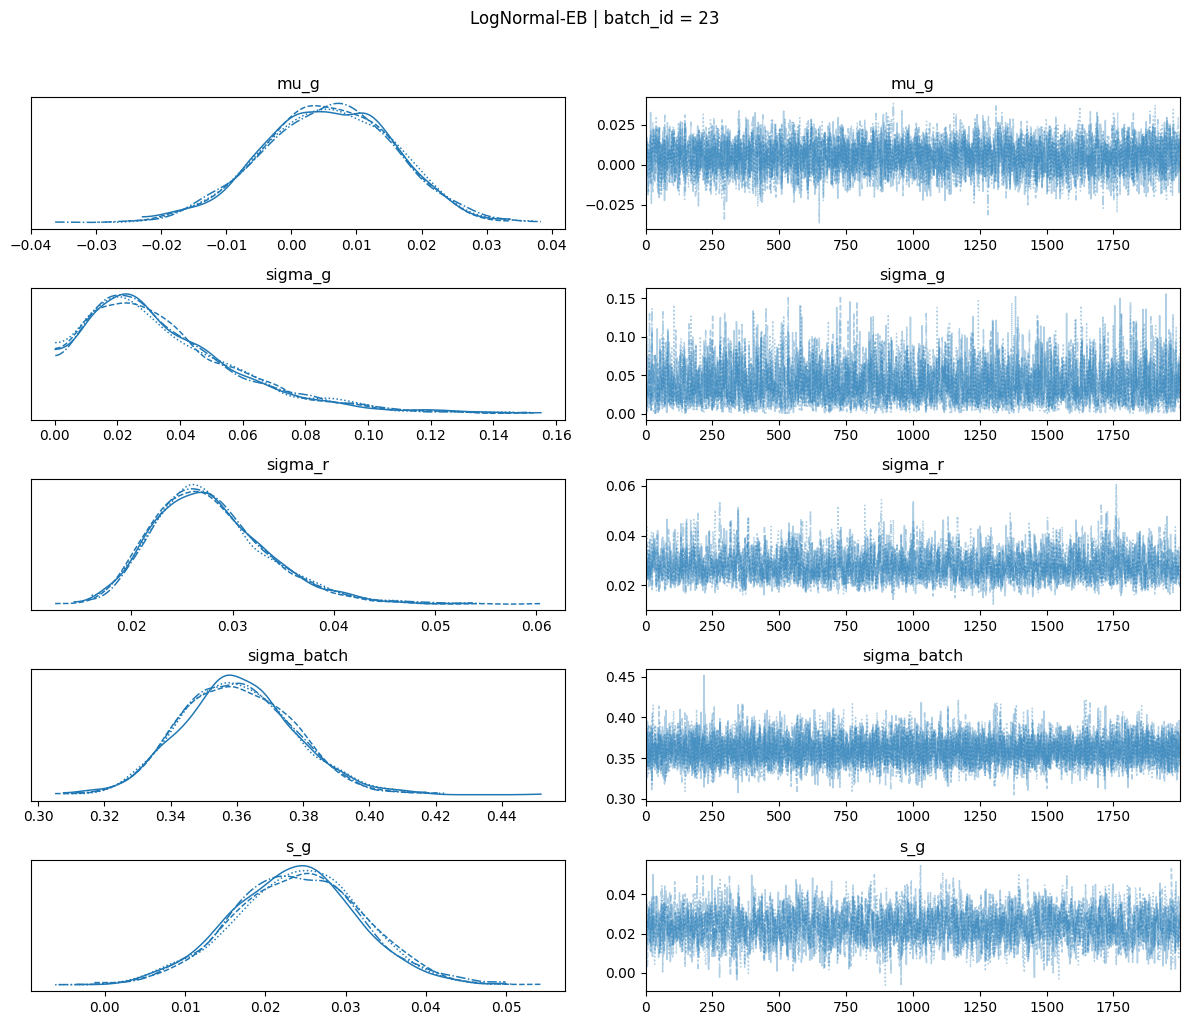

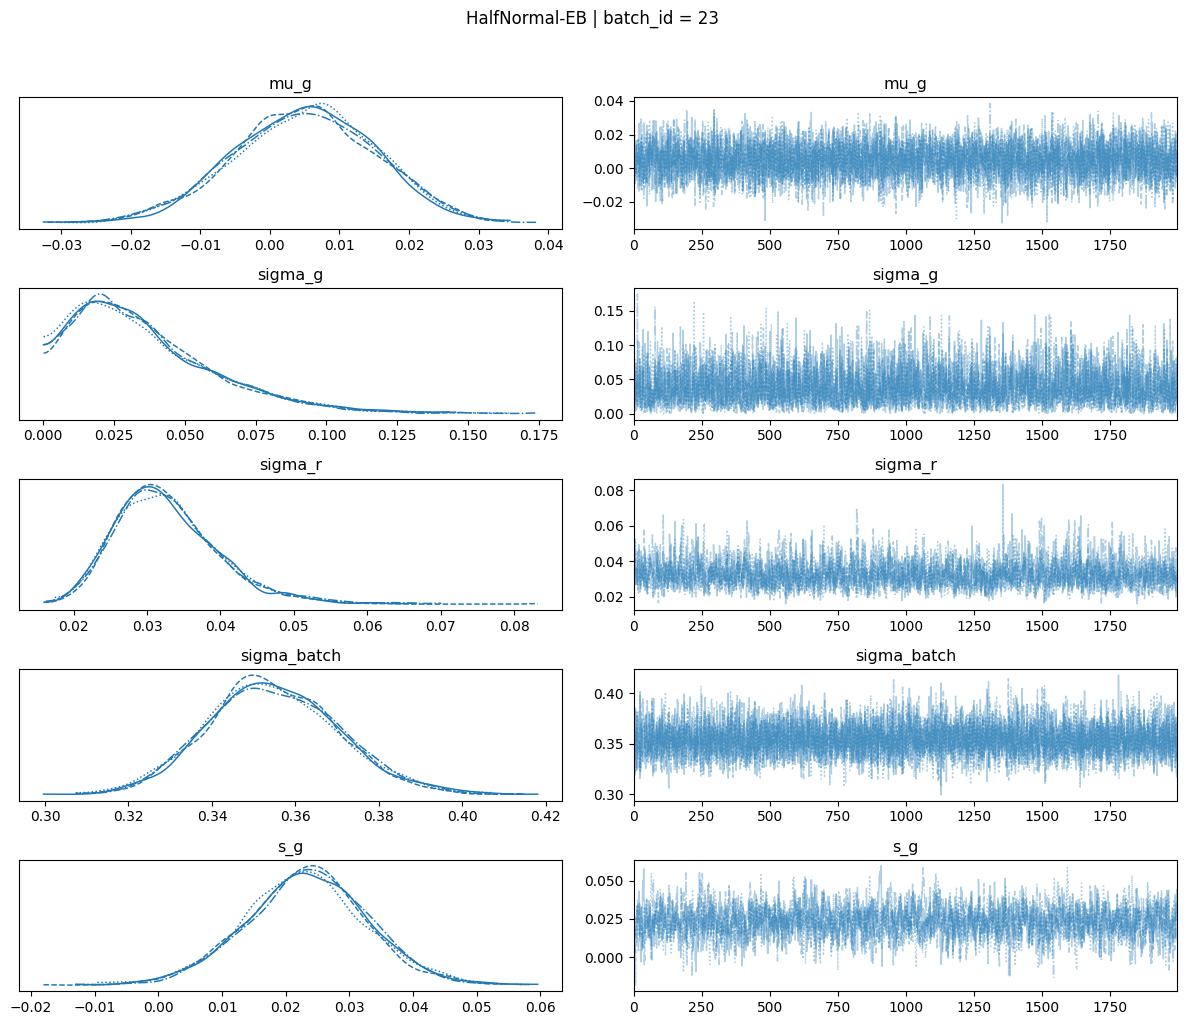

In [8]:
last_batch = batches[-1]
for label, traces in [('LogNormal-EB', model_traces_eb_logn), ('HalfNormal-EB', model_traces_eb_hn)]:
    az.plot_trace(traces[last_batch], var_names=['mu_g', 'sigma_g', 'sigma_r', 'sigma_batch', 's_g'])
    plt.suptitle(f'{label} | batch_id = {last_batch}', y=1.02)
    plt.tight_layout()
    plt.show()

In [9]:
print('LogNormal-EB â€” final batch summary')
display(az.summary(model_traces_eb_logn[batches[-1]],
                   var_names=['mu_g', 'sigma_g', 'sigma_r', 'sigma_batch', 's_g', 's_r']))
print('HalfNormal-EB â€” final batch summary')
display(az.summary(model_traces_eb_hn[batches[-1]],
                   var_names=['mu_g', 'sigma_g', 'sigma_r', 'sigma_batch', 's_g', 's_r']))

LogNormal-EB â€” final batch summary


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_g,0.006,0.010,-0.012,0.025,0.0,0.0,4391.0,4939.0,1.0
sigma_g,0.035,0.025,0.000,0.081,0.0,0.0,2668.0,2035.0,1.0
sigma_r,0.028,0.006,0.018,0.039,0.0,0.0,2598.0,4045.0,1.0
sigma_batch,0.360,0.017,0.329,0.391,0.0,0.0,7635.0,5370.0,1.0
s_g,0.024,0.008,0.008,0.039,0.0,0.0,2270.0,3807.0,1.0
s_r[0],0.002,0.014,-0.023,0.027,0.0,0.0,4838.0,5780.0,1.0
s_r[1],0.001,0.012,-0.023,0.023,0.0,0.0,4276.0,5407.0,1.0
s_r[2],0.004,0.014,-0.022,0.029,0.0,0.0,4647.0,5667.0,1.0
s_r[3],0.002,0.014,-0.025,0.026,0.0,0.0,4637.0,5646.0,1.0
s_r[4],0.019,0.013,-0.003,0.044,0.0,0.0,4360.0,5650.0,1.0


HalfNormal-EB â€” final batch summary


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_g,0.005,0.010,-0.013,0.024,0.0,0.0,5758.0,5309.0,1.0
sigma_g,0.036,0.025,0.000,0.082,0.0,0.0,3369.0,2931.0,1.0
sigma_r,0.033,0.007,0.020,0.046,0.0,0.0,2067.0,3122.0,1.0
sigma_batch,0.355,0.016,0.325,0.384,0.0,0.0,7219.0,5172.0,1.0
s_g,0.023,0.010,0.003,0.040,0.0,0.0,1661.0,2573.0,1.0
s_r[0],0.003,0.015,-0.026,0.029,0.0,0.0,3127.0,3873.0,1.0
s_r[1],0.002,0.013,-0.023,0.027,0.0,0.0,2917.0,4548.0,1.0
s_r[2],0.005,0.014,-0.021,0.033,0.0,0.0,3369.0,4709.0,1.0
s_r[3],0.002,0.014,-0.025,0.029,0.0,0.0,3195.0,4633.0,1.0
s_r[4],0.021,0.014,-0.005,0.047,0.0,0.0,2985.0,3907.0,1.0


In [10]:
for label, traces, out_dir in [('LogNormal-EB', model_traces_eb_logn, 'v2_eb_logn_traces'),
                               ('HalfNormal-EB', model_traces_eb_hn,   'v2_eb_hn_traces')]:
    os.makedirs(out_dir, exist_ok=True)
    print(f'Saving {label} traces...')
    for current_batch in batches:
        file_path = f'{out_dir}/trace_batch_{current_batch}.nc'
        if os.path.exists(file_path):
            os.remove(file_path)
        traces[current_batch].to_netcdf(file_path)
    print(f'  -> {len(batches)} files written to {out_dir}/')

Saving LogNormal-EB traces...
  -> 24 files written to v2_eb_logn_traces/
Saving HalfNormal-EB traces...
  -> 24 files written to v2_eb_hn_traces/


In [11]:
rows = []
for batch in batches:
    s_logn = az.summary(model_traces_eb_logn[batch], var_names=check_vars)
    s_hn   = az.summary(model_traces_eb_hn[batch],   var_names=check_vars)
    rows.append({
        'batch':         batch,
        'logn_max_rhat': s_logn['r_hat'].max(),
        'hn_max_rhat':   s_hn['r_hat'].max(),
        'logn_min_ess':  int(s_logn['ess_bulk'].min()),
        'hn_min_ess':    int(s_hn['ess_bulk'].min()),
    })
display(pd.DataFrame(rows))

,batch,logn_max_rhat,hn_max_rhat,logn_min_ess,hn_min_ess
0,0,1.01,1.06,570,49
1,1,1.00,1.00,4318,2180
2,2,1.00,1.00,5404,2390
3,3,1.00,1.00,2638,2904
4,4,1.00,1.00,4218,2673
5,5,1.00,1.00,3312,2713
6,6,1.00,1.00,3651,3312
7,7,1.00,1.00,2439,2169
8,8,1.00,1.00,3041,2234
9,9,1.00,1.01,2272,1541


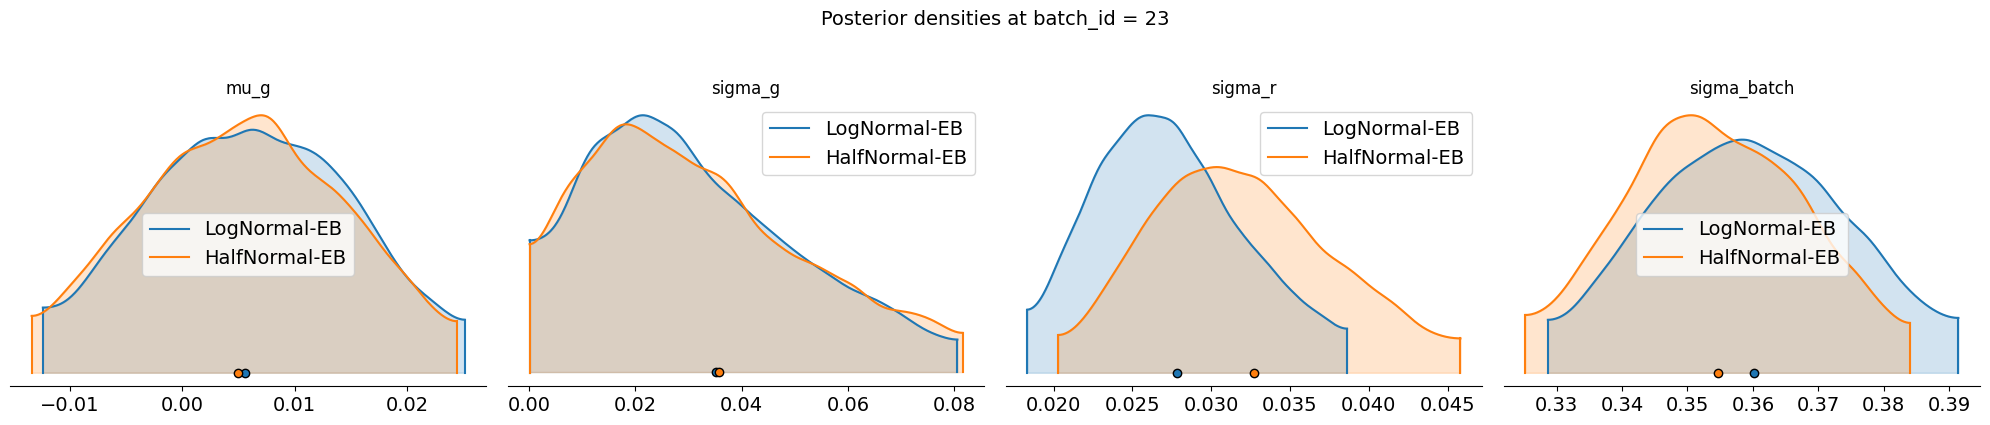

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, var in zip(axes, ['mu_g', 'sigma_g', 'sigma_r', 'sigma_batch']):
    az.plot_density(
        [model_traces_eb_logn[last_batch], model_traces_eb_hn[last_batch]],
        data_labels=['LogNormal-EB', 'HalfNormal-EB'],
        var_names=[var], ax=ax, shade=0.2,
    )
    ax.set_title(var)
plt.suptitle(f'Posterior densities at batch_id = {last_batch}', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

## Forward simulation & posterior predictive checks

All helpers below mirror the diagnostics in `model_v2.ipynb`; each is run once for the LogNormal-EB variant and once for the HalfNormal-EB variant so they can be compared directly.

In [13]:
def extract_thin_posteriors(traces_dict, baseline_array, n_thin=1000):
    extracted = {}
    for current_batch, trace in traces_dict.items():
        s_r_raw       = trace.posterior['s_r'].values
        s_g_raw       = trace.posterior['s_g'].values
        sig_batch_raw = trace.posterior['sigma_batch'].values

        s_r_flat       = s_r_raw.reshape(-1, s_r_raw.shape[-1])
        s_g_flat       = s_g_raw.flatten()
        sig_batch_flat = sig_batch_raw.flatten()

        total_samples = len(s_g_flat)
        step = max(1, total_samples // n_thin)
        s_r_thin       = s_r_flat[::step][:n_thin]
        s_g_thin       = s_g_flat[::step][:n_thin]
        sig_batch_thin = sig_batch_flat[::step][:n_thin]

        expected_b = s_r_thin + s_g_thin[:, np.newaxis] + baseline_array
        extracted[current_batch] = {'expected_b': expected_b, 'sigma_batch': sig_batch_thin}
    return extracted


def run_forward_simulation(extracted, model_data, race_data, batches, n_races,
                           seed=42, concentration_scale=20.0, drift_slope=0.01):
    rng = np.random.default_rng(seed=seed)
    final_outcomes = {}
    simulated_future = {}
    total_batches = len(batches)

    for i, current_batch in enumerate(batches):
        n_remaining = total_batches - i - 1
        cumulative_data = model_data[model_data['batch_id'] <= current_batch]
        current_data = cumulative_data.sort_values('batch_id').drop_duplicates(subset=['race_id'], keep='last')

        current_dem_votes = np.zeros(n_races)
        votes_remaining   = np.zeros(n_races)
        current_race_indices = current_data['race_id'].values
        current_dem_votes[current_race_indices] = current_data['up_to_this_batch_dem_votes'].values
        calc_remaining = current_data['final_total_votes'] - current_data['up_to_this_batch_total_votes']
        votes_remaining[current_race_indices] = np.maximum(0, calc_remaining.values)

        if n_remaining > 0:
            log_weights = np.log(1 + 1 / np.arange(1, n_remaining + 1))
            alphas = log_weights * concentration_scale
            dirichlet_draws = rng.dirichlet(alpha=alphas, size=(1000, n_races)).transpose(0, 2, 1)
            sim_batch_sizes = dirichlet_draws * votes_remaining

            exp_b_1000     = extracted[current_batch]['expected_b']
            sig_batch_1000 = extracted[current_batch]['sigma_batch']
            exp_b_reshaped     = exp_b_1000[:, np.newaxis, :]
            sig_batch_reshaped = sig_batch_1000[:, np.newaxis, np.newaxis]

            safe_sim_sizes = np.maximum(sim_batch_sizes, 1.0)
            base_sigma  = sig_batch_reshaped / (safe_sim_sizes ** 0.25)
            k_values    = np.arange(1, n_remaining + 1)[np.newaxis, :, np.newaxis]
            total_sigma = base_sigma * np.sqrt(1 + drift_slope * k_values)

            sim_dem_rates = rng.normal(loc=exp_b_reshaped, scale=total_sigma,
                                       size=(1000, n_remaining, n_races))
            sim_dem_rates = np.clip(sim_dem_rates, 0.0, 1.0)
            simulated_future[current_batch] = sim_dem_rates

            added_dem = sim_batch_sizes * sim_dem_rates
            total_added = added_dem.sum(axis=1)
            final_outcomes[current_batch] = current_dem_votes + total_added
        else:
            final_outcomes[current_batch] = np.tile(current_dem_votes, (1000, 1))
            simulated_future[current_batch] = None
    return simulated_future, final_outcomes

In [14]:
extracted_logn = extract_thin_posteriors(model_traces_eb_logn, baseline_array)
extracted_hn   = extract_thin_posteriors(model_traces_eb_hn,   baseline_array)

simulated_future_logn, final_outcomes_logn = run_forward_simulation(
    extracted_logn, model_data, race_data, batches, n_races, seed=42)
simulated_future_hn,   final_outcomes_hn   = run_forward_simulation(
    extracted_hn,   model_data, race_data, batches, n_races, seed=42)

print('Forward simulation done for both variants.')

Forward simulation done for both variants.


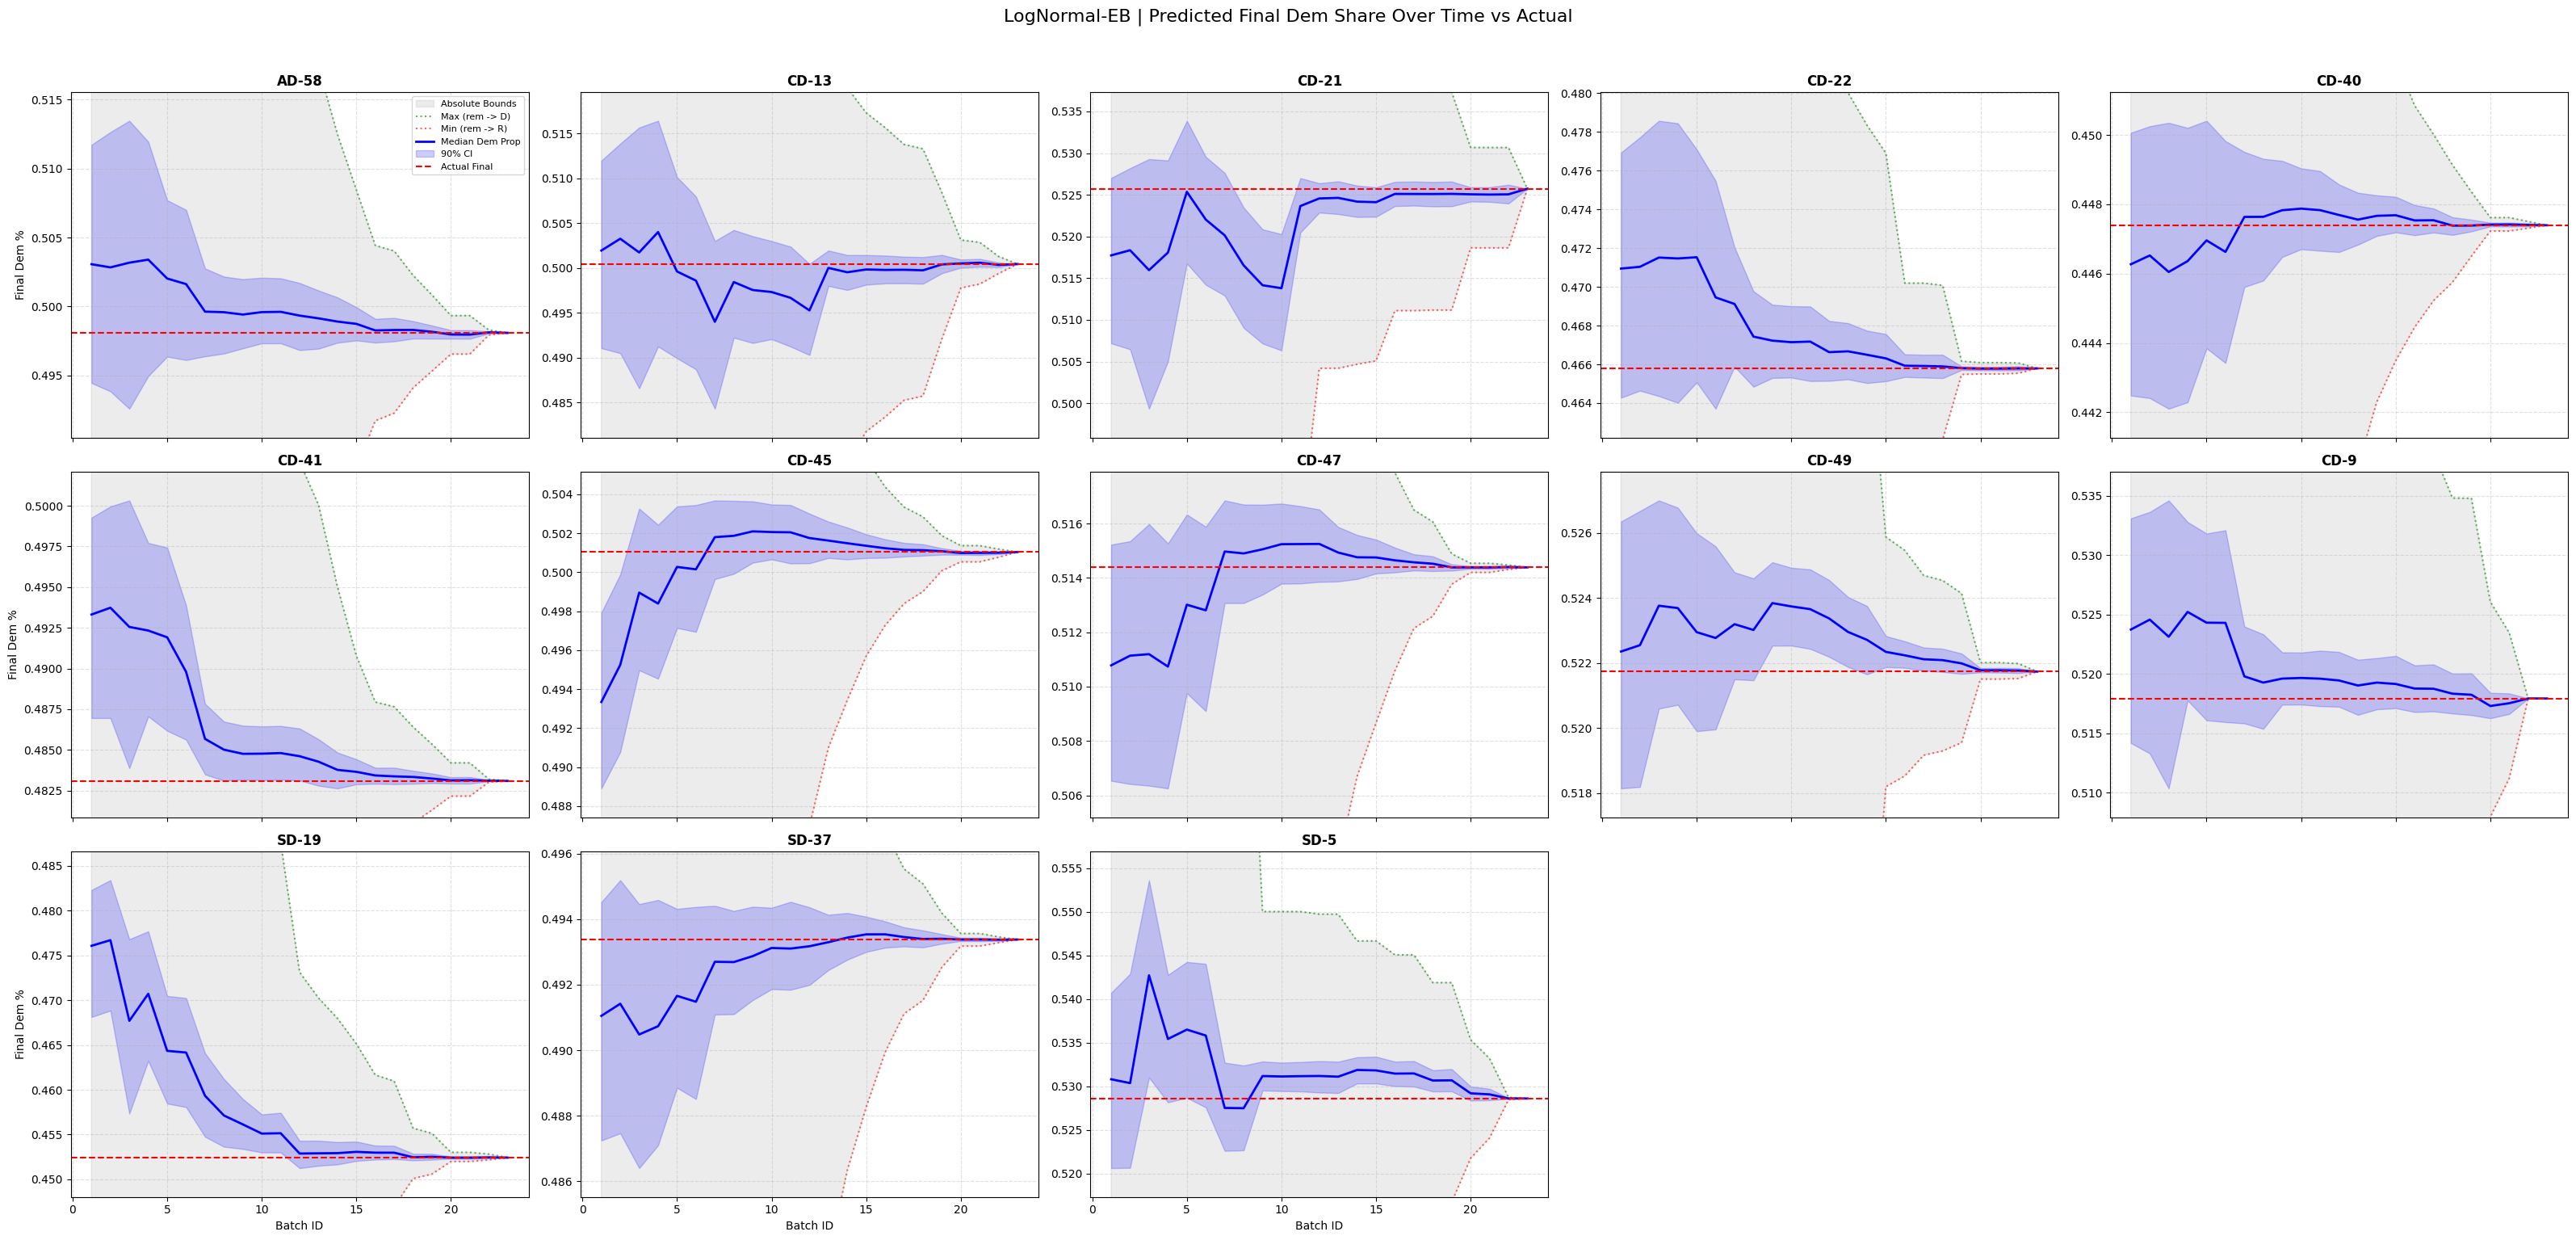

In [15]:
def plot_predicted_finals(final_outcomes_dict, race_data, model_data, batches, n_races, id_to_race, suptitle):
    batch_list = list(final_outcomes_dict.keys())
    race_denominators = race_data.sort_values('race_id')['final_total_votes'].values
    cols = 5
    rows = int(np.ceil(n_races / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(32, 5 * rows), sharex=True)
    axes = axes.flatten()

    for race_idx in range(n_races):
        ax = axes[race_idx]
        race_name = id_to_race[race_idx]
        race_denominator = race_denominators[race_idx]
        p05, p50, p95 = [], [], []
        min_bounds, max_bounds = [], []

        for b in batch_list:
            sims_prop = final_outcomes_dict[b][:, race_idx] / race_denominator
            p05.append(np.percentile(sims_prop, 5))
            p50.append(np.percentile(sims_prop, 50))
            p95.append(np.percentile(sims_prop, 95))
            cum_data = model_data[(model_data['batch_id'] <= b) & (model_data['race_id'] == race_idx)]
            if len(cum_data) > 0:
                current_dem = cum_data['up_to_this_batch_dem_votes'].iloc[-1]
                current_total = cum_data['up_to_this_batch_total_votes'].iloc[-1]
            else:
                baseline_data = race_data[race_data['race_id'] == race_idx]
                current_dem = baseline_data['baseline_dem_votes'].values[0]
                current_total = baseline_data['baseline_total_votes'].values[0]
            rem_votes = race_denominator - current_total
            min_bounds.append(current_dem / race_denominator)
            max_bounds.append((current_dem + rem_votes) / race_denominator)

        ax.fill_between(batch_list[1:], min_bounds[1:], max_bounds[1:], color='gray', alpha=0.15, label='Absolute Bounds')
        ax.plot(batch_list[1:], max_bounds[1:], color='green', linestyle=':', alpha=0.6, label='Max (rem -> D)')
        ax.plot(batch_list[1:], min_bounds[1:], color='red',   linestyle=':', alpha=0.6, label='Min (rem -> R)')
        ax.plot(batch_list[1:], p50[1:], color='blue', linewidth=2, label='Median Dem Prop')
        ax.fill_between(batch_list[1:], p05[1:], p95[1:], color='blue', alpha=0.2, label='90% CI')
        actual = race_data[race_data['race_id'] == race_idx]['final_dem_proportion'].values[0]
        ax.axhline(actual, color='red', linestyle='--', label='Actual Final')

        sim_min = min(p05[1:]); sim_max = max(p95[1:])
        plot_min = min(sim_min, actual); plot_max = max(sim_max, actual)
        y_range = plot_max - plot_min
        padding = y_range * 0.1 if y_range > 0 else 0.05
        ax.set_ylim(plot_min - padding, plot_max + padding)

        ax.set_title(race_name, fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        if race_idx % cols == 0: ax.set_ylabel('Final Dem %')
        if race_idx >= (rows - 1) * cols: ax.set_xlabel('Batch ID')

    for i in range(n_races, len(axes)):
        fig.delaxes(axes[i])
    axes[0].legend(loc='best', fontsize=8)
    plt.suptitle(suptitle, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

plot_predicted_finals(final_outcomes_logn, race_data, model_data, batches, n_races, id_to_race,
                      'LogNormal-EB | Predicted Final Dem Share Over Time vs Actual')

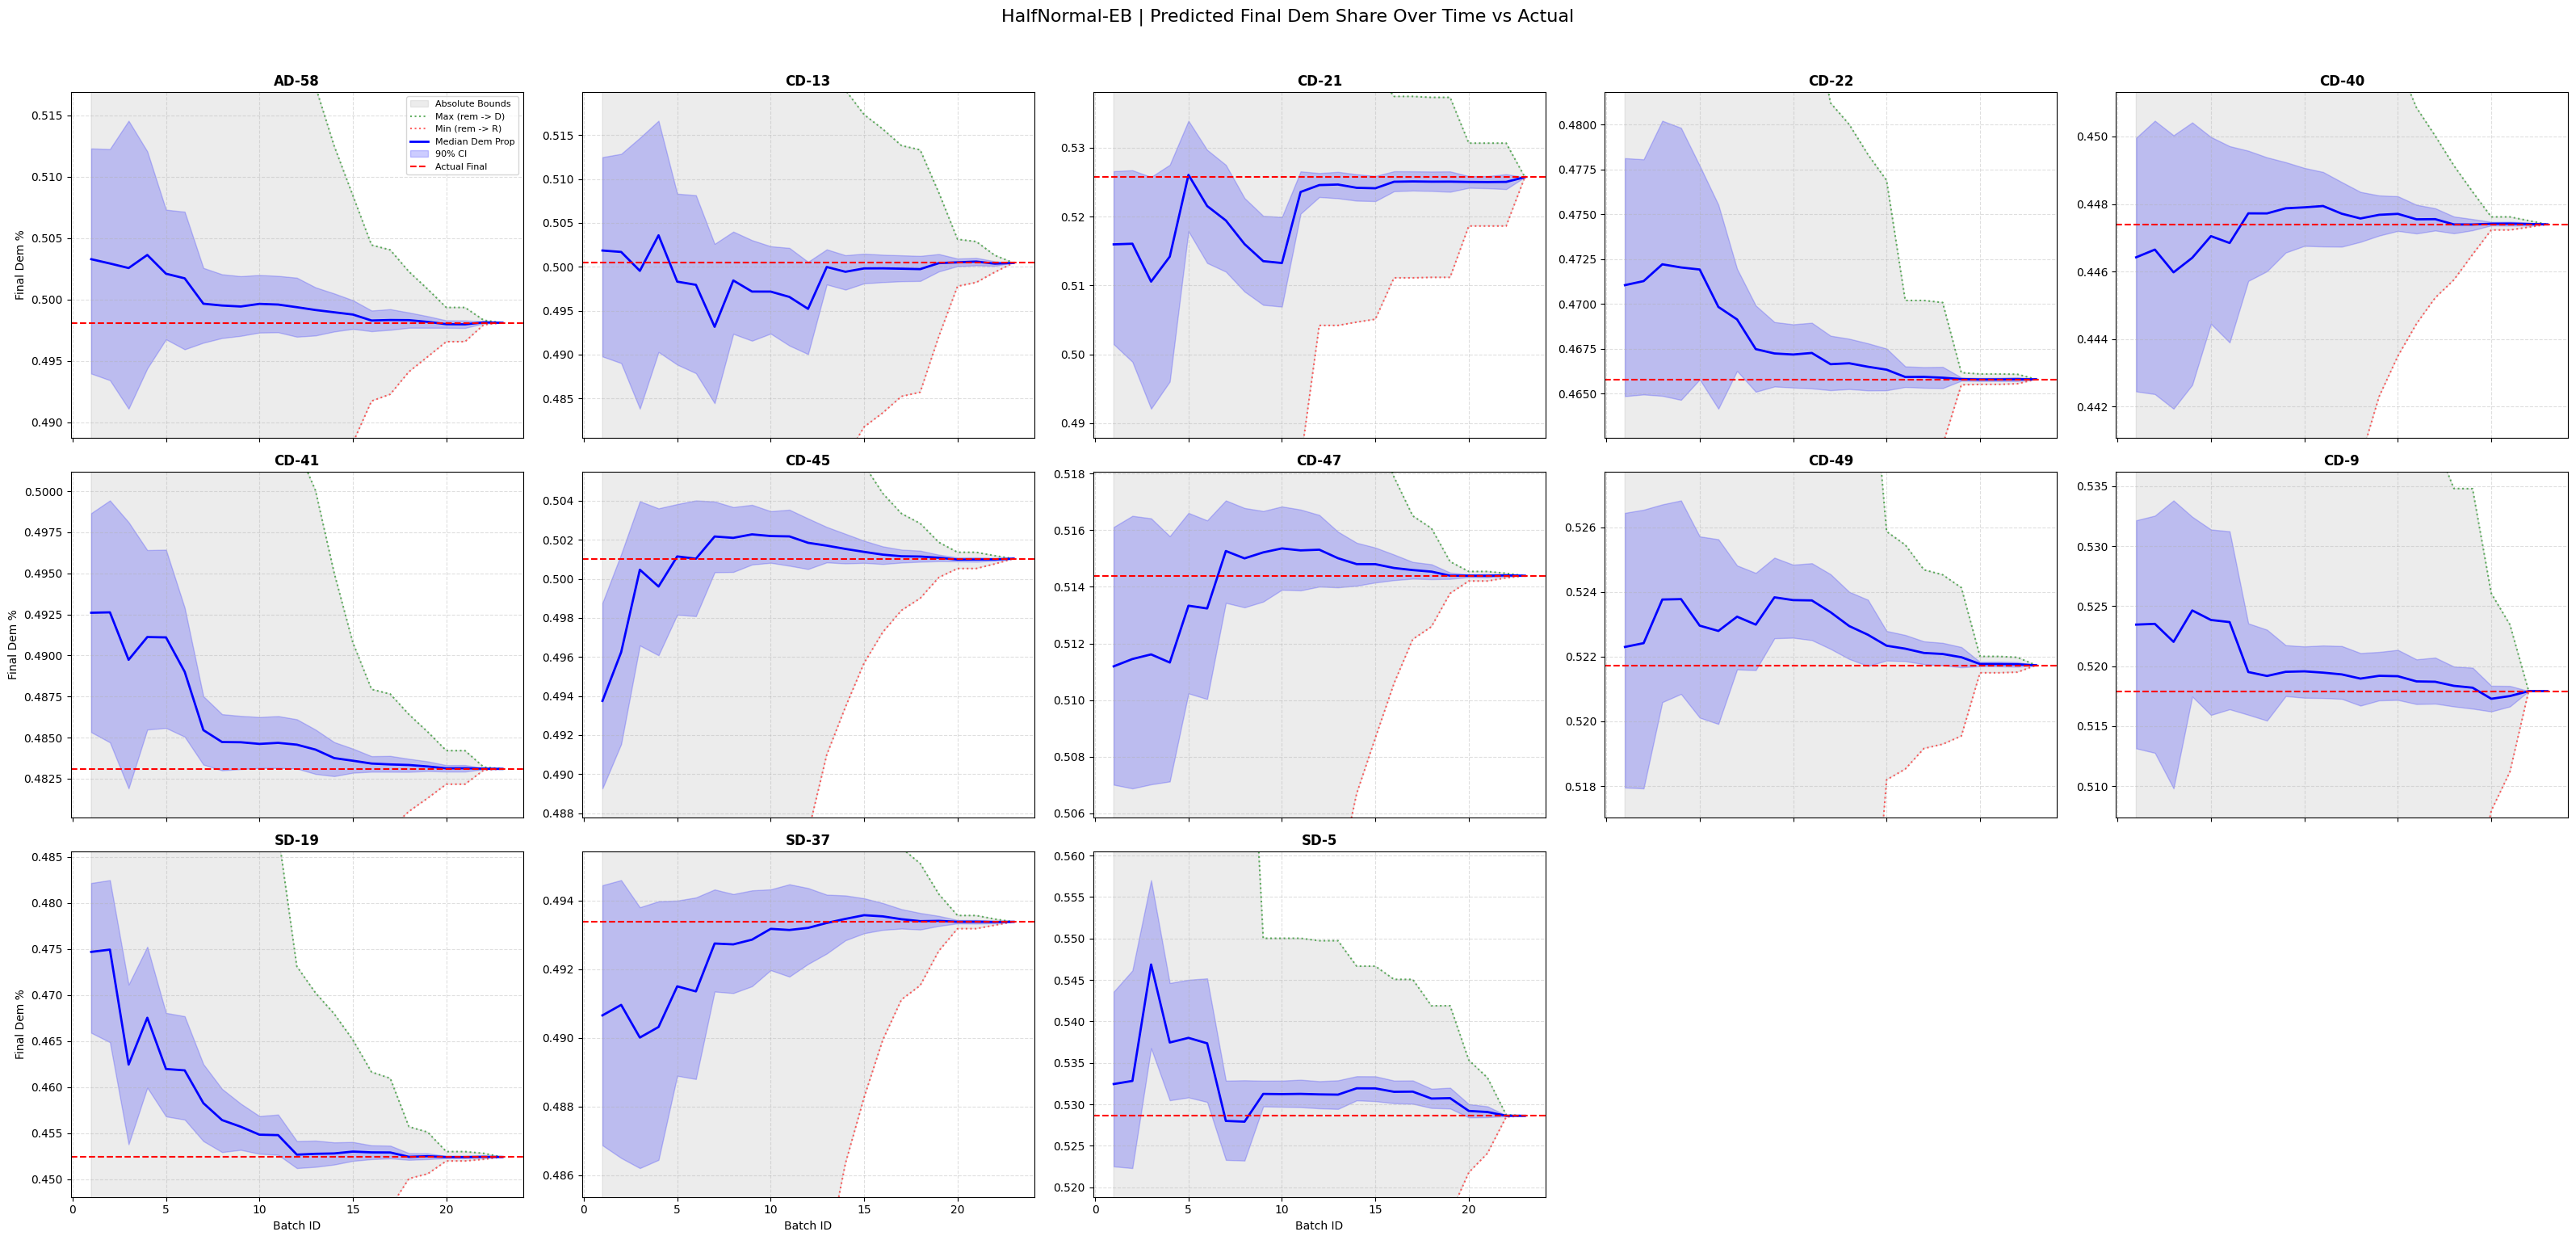

In [16]:
plot_predicted_finals(final_outcomes_hn, race_data, model_data, batches, n_races, id_to_race,
                      'HalfNormal-EB | Predicted Final Dem Share Over Time vs Actual')

In [17]:
baseline_df = model_data.copy()
baseline_df['remaining_votes'] = np.maximum(0, baseline_df['final_total_votes'] - baseline_df['up_to_this_batch_total_votes'])
baseline_df['simple_projected_dem_votes'] = (
    baseline_df['up_to_this_batch_dem_votes']
    + baseline_df['remaining_votes'] * baseline_df['up_to_this_batch_no_baseline_dem_proportion']
)
baseline_df['simple_prediction'] = baseline_df['simple_projected_dem_votes'] / baseline_df['final_total_votes']
baseline_df['simple_abs_error']  = np.abs(baseline_df['simple_prediction'] - baseline_df['final_dem_proportion'])
baseline_df['simple_sq_error']   = (baseline_df['simple_prediction'] - baseline_df['final_dem_proportion']) ** 2

all_races_ids = baseline_df['race_id'].unique()
all_batch_ids = baseline_df['batch_id'].unique()
full_grid = pd.MultiIndex.from_product([all_races_ids, all_batch_ids], names=['race_id', 'batch_id'])
df_full = baseline_df.set_index(['race_id', 'batch_id']).reindex(full_grid).reset_index().sort_values(['race_id', 'batch_id'])
df_full[['simple_prediction', 'simple_abs_error', 'simple_sq_error']] = df_full.groupby('race_id')[['simple_prediction', 'simple_abs_error', 'simple_sq_error']].ffill()
df_full = df_full.dropna(subset=['simple_abs_error'])

simple_error_summary = df_full.groupby('batch_id').agg(
    MAE_Simple=('simple_abs_error', 'mean'),
    MSE_Simple=('simple_sq_error',  'mean'),
    N_Races   =('race_id',           'count'),
).reset_index()
simple_error_summary['RMSE_Simple'] = np.sqrt(simple_error_summary['MSE_Simple'])
simple_error_summary = simple_error_summary.drop(columns=['MSE_Simple'])
display(simple_error_summary.head(10))

,batch_id,MAE_Simple,N_Races,RMSE_Simple
0,0,0.013657,12,0.019347
1,1,0.008471,13,0.012553
2,2,0.008303,13,0.012511
3,3,0.008403,13,0.012826
4,4,0.007850,13,0.011834
5,5,0.004783,13,0.005879
6,6,0.004194,13,0.005383
7,7,0.002457,13,0.003715
8,8,0.001827,13,0.002138
9,9,0.002213,13,0.002742


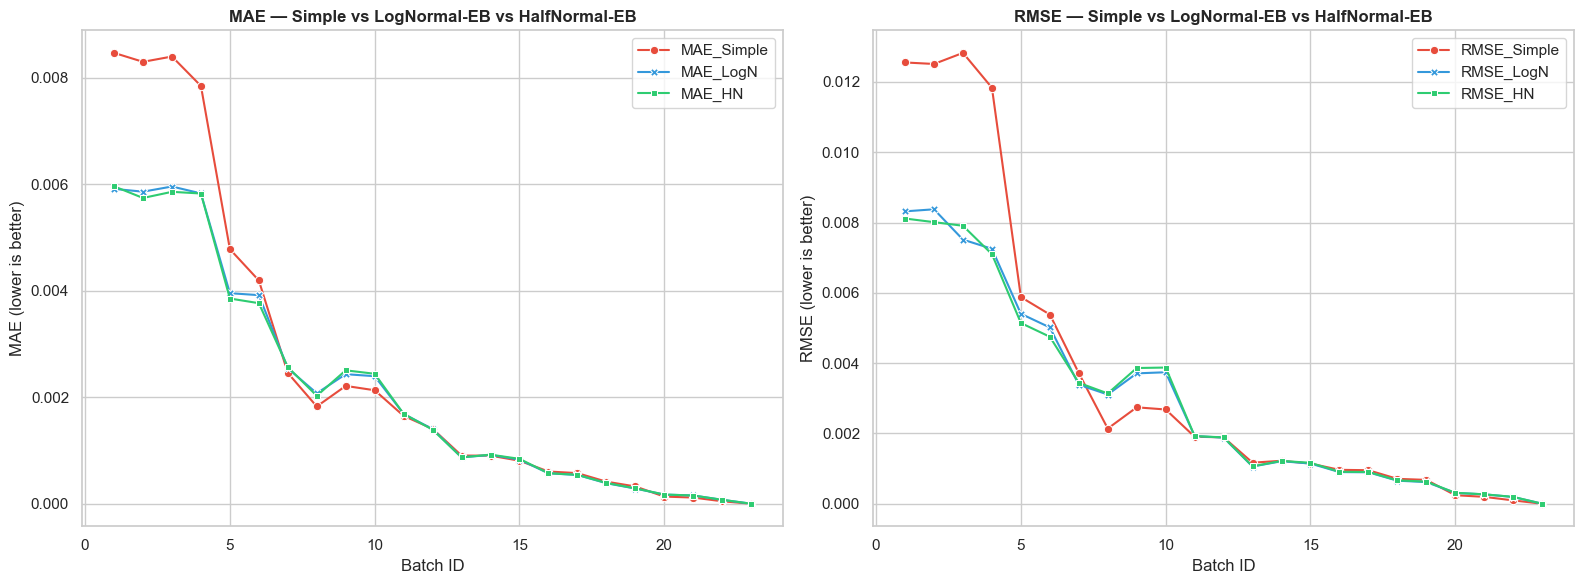

,batch_id,MAE_Simple,N_Races,RMSE_Simple,MAE_LogN,RMSE_LogN,MAE_HN,RMSE_HN
1,1,8.471227e-03,13,1.255345e-02,5.915483e-03,8.318061e-03,5.963353e-03,8.113636e-03
2,2,8.302782e-03,13,1.251073e-02,5.863048e-03,8.376121e-03,5.744694e-03,8.010408e-03
3,3,8.402717e-03,13,1.282641e-02,5.960315e-03,7.513111e-03,5.860362e-03,7.907633e-03
4,4,7.850230e-03,13,1.183446e-02,5.830595e-03,7.252530e-03,5.828613e-03,7.099970e-03
5,5,4.782802e-03,13,5.878594e-03,3.955370e-03,5.403219e-03,3.855358e-03,5.140823e-03
6,6,4.194414e-03,13,5.382608e-03,3.919113e-03,5.014759e-03,3.768005e-03,4.749762e-03
7,7,2.456824e-03,13,3.714711e-03,2.544199e-03,3.384984e-03,2.566875e-03,3.439889e-03
8,8,1.827328e-03,13,2.137611e-03,2.075177e-03,3.106628e-03,2.027966e-03,3.136886e-03
9,9,2.213302e-03,13,2.742287e-03,2.433791e-03,3.708484e-03,2.506201e-03,3.860396e-03
10,10,2.131572e-03,13,2.680556e-03,2.396183e-03,3.739865e-03,2.441346e-03,3.873938e-03


In [18]:
def mcmc_error_summary(final_outcomes_dict, race_data, batches, suffix):
    actual = race_data.sort_values('race_id')['final_dem_proportion'].values
    denoms = race_data.sort_values('race_id')['final_total_votes'].values
    records = []
    for batch in batches:
        sims = final_outcomes_dict[batch]
        pred_prop = np.median(sims, axis=0) / denoms
        records.append({
            'batch_id': batch,
            f'MAE_{suffix}': float(np.mean(np.abs(pred_prop - actual))),
            f'MSE_{suffix}': float(np.mean((pred_prop - actual) ** 2)),
        })
    out = pd.DataFrame(records)
    out[f'RMSE_{suffix}'] = np.sqrt(out[f'MSE_{suffix}'])
    return out.drop(columns=[f'MSE_{suffix}'])

mcmc_logn = mcmc_error_summary(final_outcomes_logn, race_data, batches, 'LogN')
mcmc_hn   = mcmc_error_summary(final_outcomes_hn,   race_data, batches, 'HN')

plot_df = simple_error_summary.merge(mcmc_logn, on='batch_id').merge(mcmc_hn, on='batch_id')
plot_df = plot_df[plot_df['batch_id'] != 0].copy()

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.lineplot(data=plot_df.set_index('batch_id')[['MAE_Simple', 'MAE_LogN', 'MAE_HN']],
             markers=True, dashes=False, ax=axes[0],
             palette=['#e74c3c', '#3498db', '#2ecc71'])
axes[0].set_title('MAE â€” Simple vs LogNormal-EB vs HalfNormal-EB', fontweight='bold')
axes[0].set_xlabel('Batch ID'); axes[0].set_ylabel('MAE (lower is better)')

sns.lineplot(data=plot_df.set_index('batch_id')[['RMSE_Simple', 'RMSE_LogN', 'RMSE_HN']],
             markers=True, dashes=False, ax=axes[1],
             palette=['#e74c3c', '#3498db', '#2ecc71'])
axes[1].set_title('RMSE â€” Simple vs LogNormal-EB vs HalfNormal-EB', fontweight='bold')
axes[1].set_xlabel('Batch ID'); axes[1].set_ylabel('RMSE (lower is better)')

plt.tight_layout()
plt.show()
display(plot_df)

LogNormal-EB  | predictions: 227 | mean sim var: 0.004457 | mean obs sq err: 0.006665
HalfNormal-EB | predictions: 227  | mean sim var: 0.004232  | mean obs sq err: 0.006618


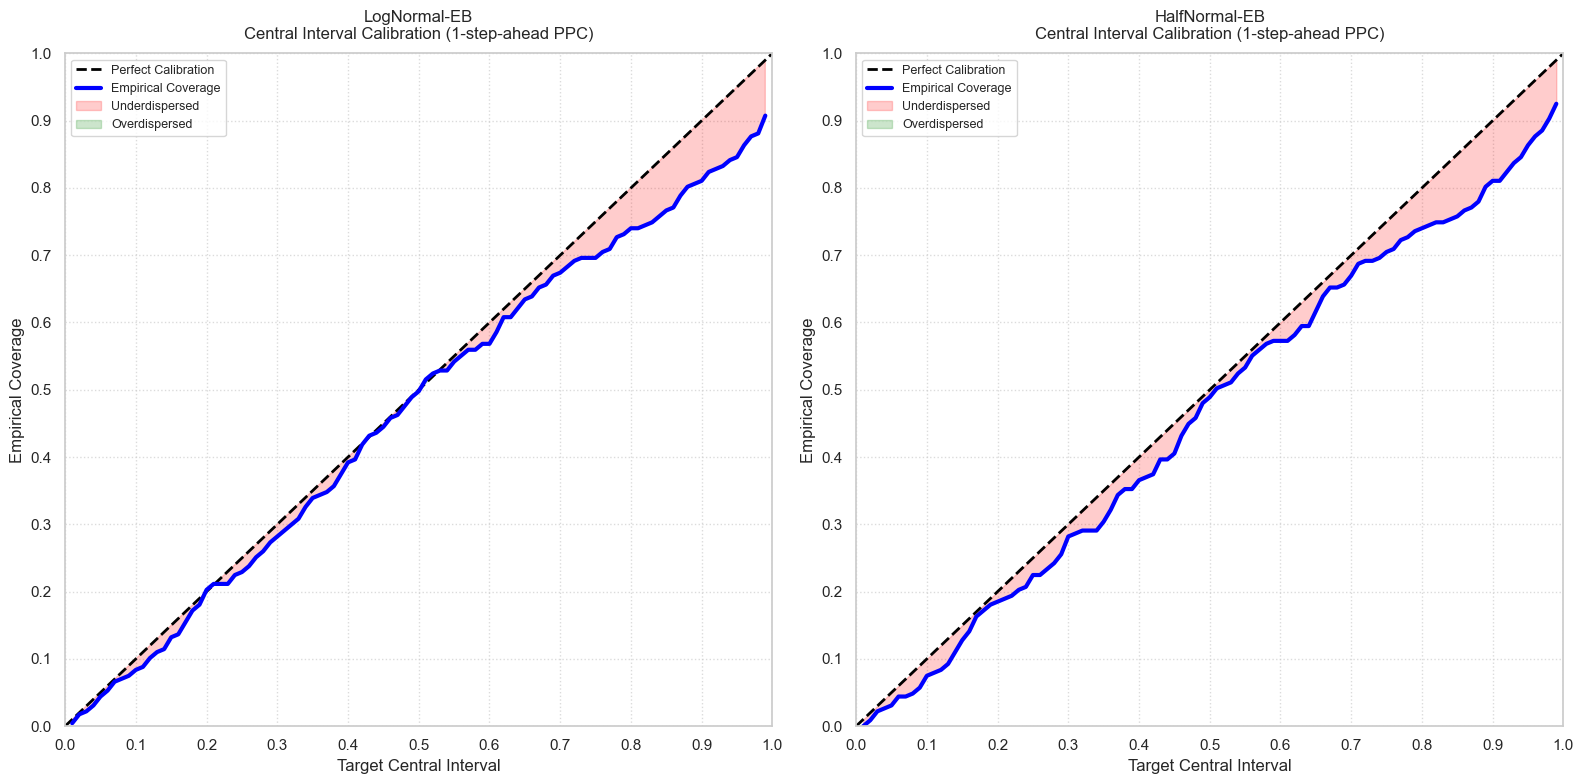

In [19]:
def calibration_curve_data(simulated_future, model_data, batches, n_races):
    target_intervals = np.linspace(0.01, 0.99, 99)
    in_counts = np.zeros(len(target_intervals))
    total = 0
    sim_var = []
    obs_jumps = []
    for i in range(len(batches) - 1):
        current_batch = batches[i]
        next_batch = batches[i + 1]
        sim_next = simulated_future[current_batch][:, 0, :]
        alphas = 1.0 - target_intervals
        low_pct = (alphas / 2.0) * 100
        up_pct  = (1.0 - alphas / 2.0) * 100
        low_bounds = np.percentile(sim_next, low_pct, axis=0)
        up_bounds  = np.percentile(sim_next, up_pct,  axis=0)
        next_batch_data = model_data[model_data['batch_id'] == next_batch]
        for race_idx in range(n_races):
            race_row = next_batch_data[next_batch_data['race_id'] == race_idx]
            if race_row.empty:
                continue
            obs_prop = race_row['this_batch_dem_proportion'].values[0]
            batch_total = race_row['this_batch_total_votes'].values[0]
            if batch_total > 0 and not np.isnan(obs_prop):
                total += 1
                inside = (obs_prop >= low_bounds[:, race_idx]) & (obs_prop <= up_bounds[:, race_idx])
                in_counts += inside
                sim_median = np.median(sim_next[:, race_idx])
                sim_var.append(np.var(sim_next[:, race_idx]))
                obs_jumps.append((obs_prop - sim_median) ** 2)
    coverage = in_counts / total if total > 0 else np.zeros_like(target_intervals)
    return target_intervals, coverage, total, float(np.mean(sim_var)), float(np.mean(obs_jumps))


ti_logn, cov_logn, n_logn, var_logn, obs_logn = calibration_curve_data(simulated_future_logn, model_data, batches, n_races)
ti_hn,   cov_hn,   n_hn,   var_hn,   obs_hn   = calibration_curve_data(simulated_future_hn,   model_data, batches, n_races)

print(f'LogNormal-EB  | predictions: {n_logn} | mean sim var: {var_logn:.6f} | mean obs sq err: {obs_logn:.6f}')
print(f'HalfNormal-EB | predictions: {n_hn}  | mean sim var: {var_hn:.6f}  | mean obs sq err: {obs_hn:.6f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, (ti, cov, label) in zip(axes, [(ti_logn, cov_logn, 'LogNormal-EB'), (ti_hn, cov_hn, 'HalfNormal-EB')]):
    ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=2, label='Perfect Calibration')
    ax.plot(ti, cov, color='blue', linewidth=3, label='Empirical Coverage')
    ax.fill_between(ti, cov, ti, where=(cov < ti), interpolate=True, color='red',   alpha=0.2, label='Underdispersed')
    ax.fill_between(ti, cov, ti, where=(cov > ti), interpolate=True, color='green', alpha=0.2, label='Overdispersed')
    ax.set_title(f'{label}\nCentral Interval Calibration (1-step-ahead PPC)', pad=10)
    ax.set_xlabel('Target Central Interval'); ax.set_ylabel('Empirical Coverage')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.1)); ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.grid(True, linestyle=':', alpha=0.7); ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()


--- LogNormal-EB | Vote-weighted sum of |slopes| ---
  T_obs           : 0.038543
  mean T_sim      : 0.030994
  p-value         : 0.1230
  conclusion      : PASS


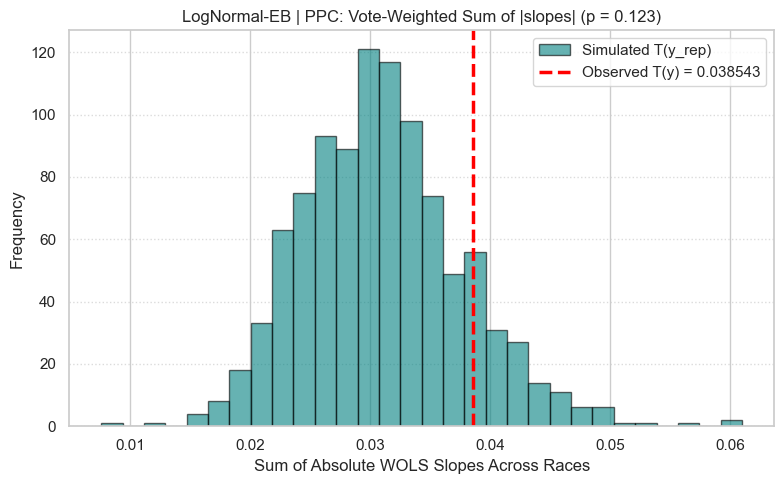


--- HalfNormal-EB | Vote-weighted sum of |slopes| ---
  T_obs           : 0.038543
  mean T_sim      : 0.032997
  p-value         : 0.2170
  conclusion      : PASS


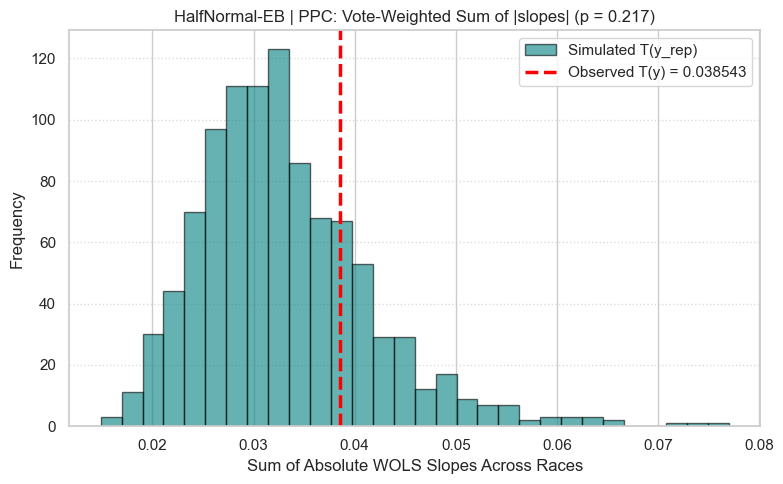

In [20]:
def vote_weighted_slopes_ppc(simulated_future, model_data, batches, n_races, label, n_sims=1000):
    n_time = len(batches) - 1
    obs_props   = np.full((n_races, n_time), np.nan)
    obs_weights = np.full((n_races, n_time), np.nan)
    sim_props   = np.full((n_sims, n_races, n_time), np.nan)

    for t_idx in range(n_time):
        current_batch = batches[t_idx]
        next_batch    = batches[t_idx + 1]
        sim_props[:, :, t_idx] = simulated_future[current_batch][:, 0, :]
        next_batch_data = model_data[model_data['batch_id'] == next_batch]
        for race_idx in range(n_races):
            race_row = next_batch_data[next_batch_data['race_id'] == race_idx]
            if not race_row.empty:
                batch_total = race_row['this_batch_total_votes'].values[0]
                if batch_total > 0:
                    obs_props[race_idx, t_idx]   = race_row['this_batch_dem_proportion'].values[0]
                    obs_weights[race_idx, t_idx] = batch_total

    T_obs = 0.0
    T_sims = np.zeros(n_sims)
    t_indices = np.arange(n_time)
    for race_idx in range(n_races):
        valid = ~np.isnan(obs_props[race_idx])
        x = t_indices[valid]
        w = obs_weights[race_idx, valid]
        if len(x) < 2 or np.sum(w) == 0:
            continue
        x_wmean = np.average(x, weights=w)
        x_dev = x - x_wmean
        SS_x_w = np.sum(w * x_dev ** 2)
        if SS_x_w == 0:
            continue
        y_obs = obs_props[race_idx, valid]
        y_obs_wmean = np.average(y_obs, weights=w)
        beta_obs = np.sum(w * x_dev * (y_obs - y_obs_wmean)) / SS_x_w
        T_obs += np.abs(beta_obs)
        y_sims = sim_props[:, race_idx, valid]
        y_sims_wmean = np.average(y_sims, weights=w, axis=1)[:, np.newaxis]
        betas_sim = np.sum(w * x_dev * (y_sims - y_sims_wmean), axis=1) / SS_x_w
        T_sims += np.abs(betas_sim)

    p_val = float(np.mean(T_sims >= T_obs))
    print(f'\n--- {label} | Vote-weighted sum of |slopes| ---')
    print(f'  T_obs           : {T_obs:.6f}')
    print(f'  mean T_sim      : {np.mean(T_sims):.6f}')
    print(f'  p-value         : {p_val:.4f}')
    verdict = 'REJECTED' if p_val <= 0.05 else ('Suspiciously flat' if p_val >= 0.95 else 'PASS')
    print(f'  conclusion      : {verdict}')
    plt.figure(figsize=(8, 5))
    plt.hist(T_sims, bins=30, color='teal', alpha=0.6, edgecolor='black', label='Simulated T(y_rep)')
    plt.axvline(T_obs, color='red', linestyle='--', linewidth=2.5, label=f'Observed T(y) = {T_obs:.6f}')
    plt.title(f'{label} | PPC: Vote-Weighted Sum of |slopes| (p = {p_val:.3f})')
    plt.xlabel('Sum of Absolute WOLS Slopes Across Races'); plt.ylabel('Frequency')
    plt.legend(); plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout(); plt.show()
    return T_obs, T_sims, p_val

_ = vote_weighted_slopes_ppc(simulated_future_logn, model_data, batches, n_races, 'LogNormal-EB')
_ = vote_weighted_slopes_ppc(simulated_future_hn,   model_data, batches, n_races, 'HalfNormal-EB')


--- LogNormal-EB | Percentile Calibration Decay ---
  pairs evaluated : 2902
  T_obs_slope     : 0.002588
  mean T_sim_slope: 0.000000
  p-value         : 0.0020
  conclusion      : SEVERE DECAY (drift into tails)


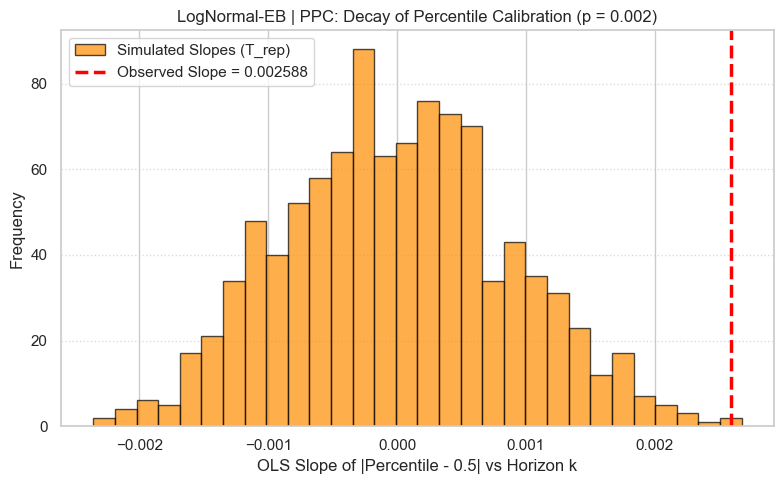


--- HalfNormal-EB | Percentile Calibration Decay ---
  pairs evaluated : 2902
  T_obs_slope     : 0.002429
  mean T_sim_slope: 0.000000
  p-value         : 0.0070
  conclusion      : SEVERE DECAY (drift into tails)


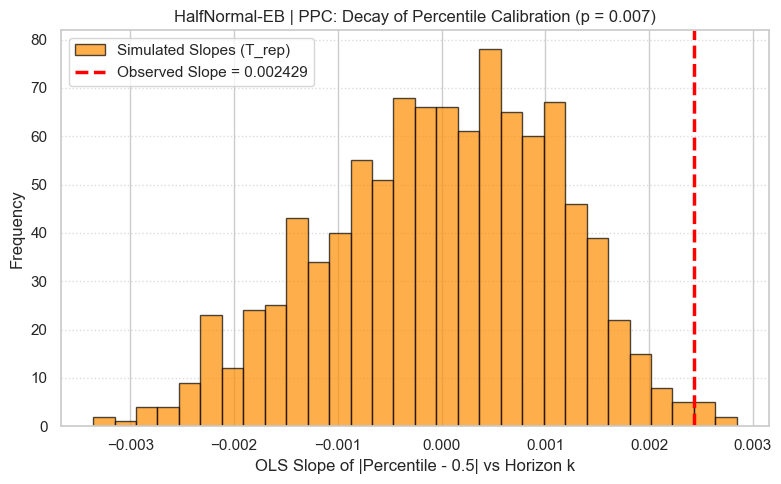

In [21]:
def percentile_dispersion_ppc(simulated_future, model_data, batches, n_races, label, n_sims=1000):
    n_time = len(batches) - 1
    k_values = []
    obs_metrics = []
    sim_metrics_dict = {s: [] for s in range(n_sims)}
    for t_idx in range(n_time):
        current_batch = batches[t_idx]
        sims_from_t = simulated_future[current_batch]
        n_future = sims_from_t.shape[1]
        for k_idx in range(n_future):
            k = k_idx + 1
            target_batch = batches[t_idx + k]
            target_data = model_data[model_data['batch_id'] == target_batch]
            for race_idx in range(n_races):
                race_row = target_data[target_data['race_id'] == race_idx]
                if race_row.empty:
                    continue
                batch_total = race_row['this_batch_total_votes'].values[0]
                if batch_total <= 0:
                    continue
                obs_prop = race_row['this_batch_dem_proportion'].values[0]
                if np.isnan(obs_prop):
                    continue
                sim_arr = sims_from_t[:, k_idx, race_idx]
                obs_pct = np.mean(sim_arr <= obs_prop)
                obs_metric = np.abs(obs_pct - 0.50)
                sim_ranks = rankdata(sim_arr)
                sim_pcts = sim_ranks / n_sims
                sim_metric_array = np.abs(sim_pcts - 0.50)
                k_values.append(k)
                obs_metrics.append(obs_metric)
                for s in range(n_sims):
                    sim_metrics_dict[s].append(sim_metric_array[s])

    k_array = np.array(k_values)
    obs_Y = np.array(obs_metrics)
    sim_Y_matrix = np.array([sim_metrics_dict[s] for s in range(n_sims)])
    k_mean = np.mean(k_array)
    k_dev = k_array - k_mean
    SS_k = np.sum(k_dev ** 2)
    obs_Y_mean = np.mean(obs_Y)
    T_obs_slope = np.sum(k_dev * (obs_Y - obs_Y_mean)) / SS_k
    sim_Y_means = np.mean(sim_Y_matrix, axis=1, keepdims=True)
    T_sim_slopes = np.sum(k_dev * (sim_Y_matrix - sim_Y_means), axis=1) / SS_k
    p_val = float(np.mean(T_sim_slopes >= T_obs_slope))

    print(f'\n--- {label} | Percentile Calibration Decay ---')
    print(f'  pairs evaluated : {len(k_array)}')
    print(f'  T_obs_slope     : {T_obs_slope:.6f}')
    print(f'  mean T_sim_slope: {np.mean(T_sim_slopes):.6f}')
    print(f'  p-value         : {p_val:.4f}')
    verdict = 'SEVERE DECAY (drift into tails)' if p_val <= 0.05 else 'PASS - dispersion stable across horizons'
    print(f'  conclusion      : {verdict}')
    plt.figure(figsize=(8, 5))
    plt.hist(T_sim_slopes, bins=30, color='darkorange', alpha=0.7, edgecolor='black', label='Simulated Slopes (T_rep)')
    plt.axvline(T_obs_slope, color='red', linestyle='--', linewidth=2.5, label=f'Observed Slope = {T_obs_slope:.6f}')
    plt.title(f'{label} | PPC: Decay of Percentile Calibration (p = {p_val:.3f})')
    plt.xlabel('OLS Slope of |Percentile - 0.5| vs Horizon k'); plt.ylabel('Frequency')
    plt.legend(); plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout(); plt.show()
    return T_obs_slope, T_sim_slopes, p_val

_ = percentile_dispersion_ppc(simulated_future_logn, model_data, batches, n_races, 'LogNormal-EB')
_ = percentile_dispersion_ppc(simulated_future_hn,   model_data, batches, n_races, 'HalfNormal-EB')

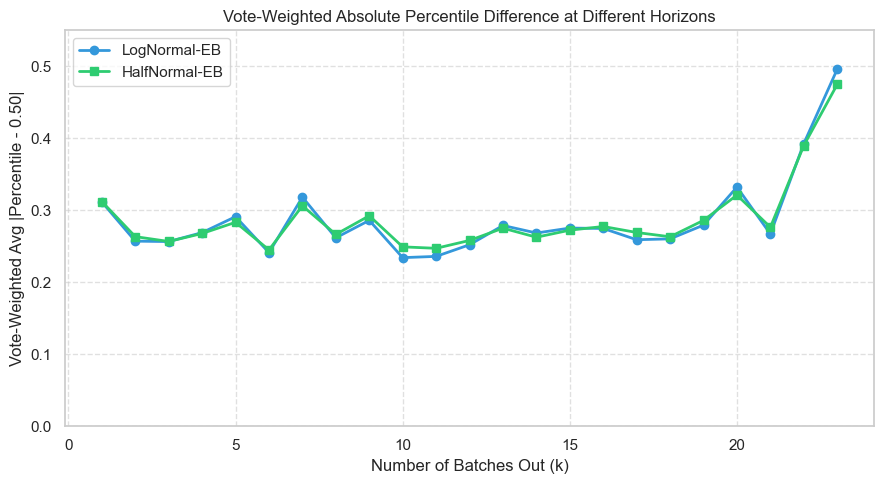

In [22]:
def future_dispersion_df(simulated_future, model_data, batches, n_races):
    k_values, obs_metrics, weights = [], [], []
    n_time = len(batches) - 1
    for t_idx in range(n_time):
        current_batch = batches[t_idx]
        sims_from_t = simulated_future[current_batch]
        n_future = sims_from_t.shape[1]
        for k_idx in range(n_future):
            k = k_idx + 1
            target_batch = batches[t_idx + k]
            target_data = model_data[model_data['batch_id'] == target_batch]
            for race_idx in range(n_races):
                race_row = target_data[target_data['race_id'] == race_idx]
                if race_row.empty:
                    continue
                batch_total = race_row['this_batch_total_votes'].values[0]
                if batch_total <= 0:
                    continue
                obs_prop = race_row['this_batch_dem_proportion'].values[0]
                if np.isnan(obs_prop):
                    continue
                sim_arr = sims_from_t[:, k_idx, race_idx]
                obs_pct = np.mean(sim_arr <= obs_prop)
                k_values.append(k)
                obs_metrics.append(np.abs(obs_pct - 0.50))
                weights.append(batch_total)
    return pd.DataFrame({'k': k_values, 'Abs_Pct_Diff': obs_metrics, 'Weight': weights})


zk_logn = future_dispersion_df(simulated_future_logn, model_data, batches, n_races)
zk_hn   = future_dispersion_df(simulated_future_hn,   model_data, batches, n_races)

wm_logn = zk_logn.groupby('k').apply(lambda x: np.average(x['Abs_Pct_Diff'], weights=x['Weight']))
wm_hn   = zk_hn.groupby('k').apply(  lambda x: np.average(x['Abs_Pct_Diff'], weights=x['Weight']))

fig, ax = plt.subplots(figsize=(9, 5))
wm_logn.plot(ax=ax, marker='o', linewidth=2, label='LogNormal-EB', color='#3498db')
wm_hn.plot(  ax=ax, marker='s', linewidth=2, label='HalfNormal-EB', color='#2ecc71')
ax.set_xlabel('Number of Batches Out (k)')
ax.set_ylabel('Vote-Weighted Avg |Percentile - 0.50|')
ax.set_ylim((0, 0.55))
ax.set_title('Vote-Weighted Absolute Percentile Difference at Different Horizons')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()